In [ ]:
from tasks.safety_monitor import SafetyMonitor, SM_CFG


import numpy as np
import matplotlib.pyplot as plt

In [2]:
import numpy as np

class RFF:
    def __init__(self, gamma: float, D: int, N: int, C: int, dt: float = 1.0):
        self.D = D
        scale = np.sqrt(2 * gamma * dt) 
        self.w = np.random.randn(D, N, C) * scale
        self.b = np.random.uniform(0, 2 * np.pi, size=D)

    def transform(self, x: np.ndarray):
        projection = np.einsum('bij,dij->bd', x, self.w)
        z = np.sqrt(2 / self.D) * np.cos(projection + self.b)
        
        return z

In [24]:
task = SafetyMonitor('hopper', SM_CFG['hopper'])
x_tr, x_te = task.get_train_test()
y_true = task.y_true

starts = np.random.randint(low=100, high=x_tr.shape[1] - 70 + 1, size=len(x_tr))
idx = starts[:, None] + np.arange(70)[None, :]
x_tr = x_tr[np.arange(len(x_tr))[:, None], idx]

Sampled windows from 1000 / 1000 trajectories


In [25]:
x_tr.shape

(283, 70, 11)

In [51]:
rff = RFF(gamma=.005, D = 300, N = 70, C = 11)

z_tr = rff.transform(x_tr)
z_te = rff.transform(x_te)

z_tr.mean()

np.float64(0.0003992687938519416)

In [52]:
z_tr.shape

(283, 300)

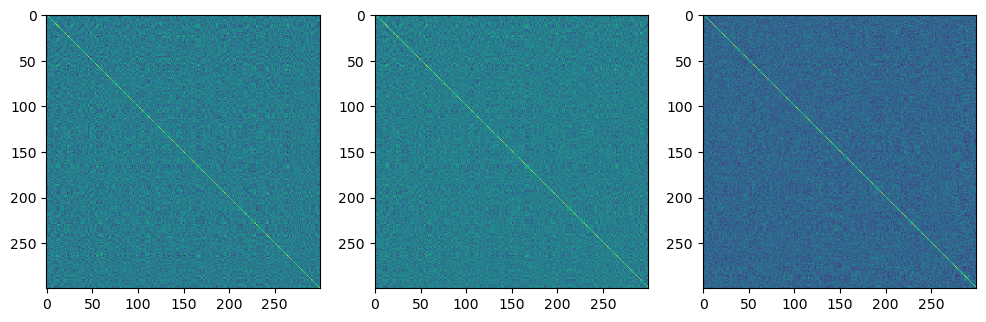

In [53]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(z_tr.T @ z_tr)
ax[1].imshow(z_te[~y_true].T @ z_te[~y_true])
ax[2].imshow(z_te[y_true].T @ z_te[y_true])

In [54]:
from cd.algs.kern_cd import KernCD
from cd.algs.cd_poly import CDPolynomial
from cd.algs.kernels import RBF

In [57]:
kern = KernCD(RBF(gamma=.5), lam=1e-7).fit(z_tr)
poly = CDPolynomial(z_tr, degree=1, method='chol', eps=1e-6)

In [58]:
kern_scores = kern.predict(z_te)
poly_scores = poly(z_te)

(array([223.,  14.,  10.,  10.,   3.,   6.,  10.,  10.,   5.,   3.]),
 array([   593.64466845,  18846.35990868,  37099.0751489 ,  55351.79038913,
         73604.50562935,  91857.22086958, 110109.9361098 , 128362.65135003,
        146615.36659025, 164868.08183048, 183120.7970707 ]),
 <BarContainer object of 10 artists>)

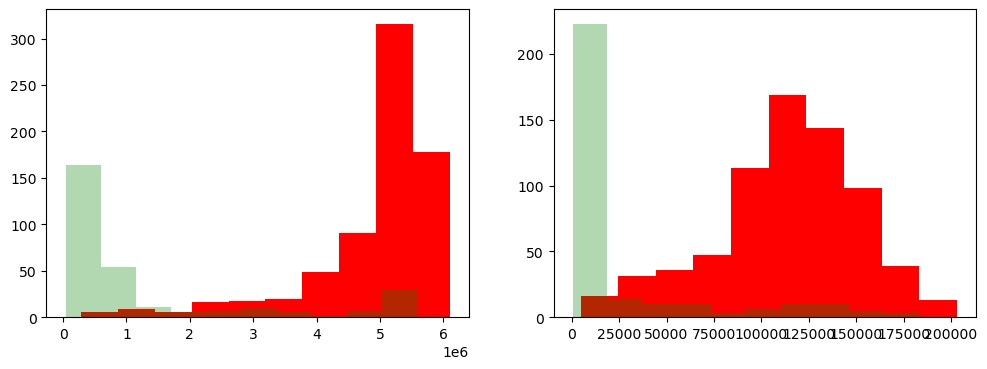

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(kern_scores[y_true], color='red')
ax[0].hist(kern_scores[~y_true], color='green', alpha=0.3)

ax[1].hist(poly_scores[y_true], color='red')
ax[1].hist(poly_scores[~y_true], color='green', alpha=0.3)